In [92]:
pip install streamlit nltk sentence_transformers seaborn re

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement re (from versions: none)
ERROR: No matching distribution found for re


In [93]:
import numpy as np
import pandas as pd
import nltk
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.metrics.pairwise import linear_kernel,cosine_similarity
import seaborn as sns
from ast import literal_eval
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [94]:
df = pd.read_csv('archive\TMDB_IMDB_Movies_Dataset.csv')


## Looking at starting rows of both dataframes to get idea what we are dealing with

In [95]:
print("First 5 Data:")
df.head()

First 5 Data:


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2803919,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2507863,"Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3154204,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1492626,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1553233,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 436608 entries, 0 to 436607
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    436608 non-null  int64  
 1   title                 436608 non-null  str    
 2   vote_average          436608 non-null  float64
 3   vote_count            436608 non-null  int64  
 4   status                436608 non-null  str    
 5   release_date          415165 non-null  str    
 6   revenue               436608 non-null  int64  
 7   runtime               436608 non-null  int64  
 8   adult                 436608 non-null  bool   
 9   backdrop_path         185342 non-null  str    
 10  budget                436608 non-null  int64  
 11  homepage              54796 non-null   str    
 12  tconst                436608 non-null  str    
 13  original_language     436608 non-null  str    
 14  original_title        436608 non-null  str    
 15  overview   

In [97]:
df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity,averageRating,numVotes
count,4.366080e+05,436608.000000,436608.000000,4.366080e+05,436608.000000,4.366080e+05,436608.000000,436608.000000,4.366080e+05
mean,4.940726e+05,3.598071,48.809788,1.650923e+06,66.448118,6.480355e+05,2.192268,6.229217,3.102911e+03
std,3.645316e+05,3.150351,512.486102,2.617105e+07,63.916931,7.409076e+06,11.337911,1.309834,3.397957e+04
min,2.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000,5.000000e+00
25%,2.101930e+05,0.000000,0.000000,0.000000e+00,15.000000,0.000000e+00,0.600000,5.400000,2.300000e+01
50%,4.193680e+05,4.600000,1.000000,0.000000e+00,80.000000,0.000000e+00,0.853000,6.300000,7.000000e+01
75%,7.116682e+05,6.200000,6.000000,0.000000e+00,96.000000,0.000000e+00,1.656000,7.100000,3.200000e+02
max,1.664509e+06,10.000000,34495.000000,2.923706e+09,14400.000000,8.880000e+08,2994.357000,10.000000,3.175039e+06


In [98]:
df.isnull()
df.isnull().sum()

id                           0
title                        0
vote_average                 0
vote_count                   0
status                       0
release_date             21443
revenue                      0
runtime                      0
adult                        0
backdrop_path           251266
budget                       0
homepage                381812
tconst                       0
original_language            0
original_title               0
overview                 43010
popularity                   0
poster_path              75981
tagline                 344367
genres                   79787
production_companies    174674
production_countries    115877
spoken_languages        104518
keywords                265888
directors                 9946
writers                  65025
averageRating                0
numVotes                     0
cast                     68826
dtype: int64

In [99]:
#since we have no use of these data does not matter for the recommendation system so I drop it
df = df.drop(columns=['homepage', 'backdrop_path', 'poster_path'])

In [100]:
df.isnull().sum()

id                           0
title                        0
vote_average                 0
vote_count                   0
status                       0
release_date             21443
revenue                      0
runtime                      0
adult                        0
budget                       0
tconst                       0
original_language            0
original_title               0
overview                 43010
popularity                   0
tagline                 344367
genres                   79787
production_companies    174674
production_countries    115877
spoken_languages        104518
keywords                265888
directors                 9946
writers                  65025
averageRating                0
numVotes                     0
cast                     68826
dtype: int64

In [101]:
#main feauture will be  = overview + genres + keywords + cast + directors
#checking for text normalization
df['genres'].iloc[0]
df['overview'].iloc[1]

'The adventures of a group of explorers who make use of a newly discovered wormhole to surpass the limitations on human space travel and conquer the vast distances involved in an interstellar voyage.'

In [102]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # lowercase
    text = text.lower()
    
    # remove special characters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # tokenize
    words = text.split()
    
    # remove stopwords + lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jirat\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jirat\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [103]:
df.isnull().sum()

id                           0
title                        0
vote_average                 0
vote_count                   0
status                       0
release_date             21443
revenue                      0
runtime                      0
adult                        0
budget                       0
tconst                       0
original_language            0
original_title               0
overview                 43010
popularity                   0
tagline                 344367
genres                   79787
production_companies    174674
production_countries    115877
spoken_languages        104518
keywords                265888
directors                 9946
writers                  65025
averageRating                0
numVotes                     0
cast                     68826
dtype: int64

In [104]:
#due to the high amount of data, we would like to use only the top 20000 based on the imdb Weighted Average Ratings
m = df['vote_count'].quantile(0.9)
C = df['vote_average'].mean()

#Defining Formula for calculating the score of each movie
def weight_average(x):
    v = x['vote_count']
    R = x['vote_average']
    return (v/(v+m))*R + (m/(v+m))*C

#Filtering Dataframe to get movies with vote count >= m
q_movies = df.copy().loc[df['vote_count'] >= m]
q_movies.shape


(44564, 26)

In [105]:
#Adding new feature 'score' according to IMDB formula to rank these movies rating-wise
q_movies['score'] = q_movies.apply(weight_average , axis = 1)
q_movies.shape

(44564, 27)

In [106]:
#Sorting According to 'Score' attribute and find top 20 IMDB rated movies
q_movies = q_movies.sort_values('score' , ascending = False)
q_movies[['title','score','vote_average','vote_count']].head(20)

,title,score,vote_average,vote_count
53,The Godfather,8.700443,8.707,18677
14,The Shawshank Redemption,8.697035,8.702,24649
215,The Godfather Part II,8.580411,8.591,11293
119,Schindler's List,8.564832,8.573,14594
107,Spirited Away,8.531061,8.539,14913
436,12 Angry Men,8.524560,8.540,7658
991,Dilwale Dulhania Le Jayenge,8.524221,8.552,4256
2,The Dark Knight,8.508151,8.512,30619
81,Parasite,8.507828,8.515,16430
258,Your Name.,8.502575,8.514,10303


In [107]:
#Keep top 20,000
df_model = q_movies.sort_values('score', ascending=False).head(20000).copy()

# remove duplicate titles
df_model = df_model.drop_duplicates(subset='title').reset_index(drop=True)

In [108]:
df_model.isnull().sum()

id                         0
title                      0
vote_average               0
vote_count                 0
status                     0
release_date               0
revenue                    0
runtime                    0
adult                      0
budget                     0
tconst                     0
original_language          0
original_title             0
overview                  52
popularity                 0
tagline                 7411
genres                    22
production_companies     644
production_countries     199
spoken_languages          58
keywords                2403
directors                 47
writers                  668
averageRating              0
numVotes                   0
cast                     195
score                      0
dtype: int64

In [109]:
# Heavy cleaning for text fields
for feature in ['overview']:
    df_model[feature] = df_model[feature].fillna('').apply(clean_text)

# Light cleaning for categorical text
for feature in ['genres', 'keywords']:
    df_model[feature] = df_model[feature].fillna('').str.lower()

# Special handling for names
for feature in ['cast', 'directors']:
    df_model[feature] = df_model[feature].fillna('').str.lower()
    df_model[feature] = df_model[feature].str.replace(' ', '', regex=False)

In [110]:
df_model.isnull().sum()

id                         0
title                      0
vote_average               0
vote_count                 0
status                     0
release_date               0
revenue                    0
runtime                    0
adult                      0
budget                     0
tconst                     0
original_language          0
original_title             0
overview                   0
popularity                 0
tagline                 7411
genres                     0
production_companies     644
production_countries     199
spoken_languages          58
keywords                   0
directors                  0
writers                  668
averageRating              0
numVotes                   0
cast                       0
score                      0
dtype: int64

In [111]:
df_model['soup'] = (
    df_model['overview'] + ' ' +
    df_model['genres'] + ' ' +
    df_model['keywords'] + ' ' +
    df_model['cast'] + ' ' +
    df_model['directors']
)

In [112]:
#df_model['soup'].tolist()

In [113]:
# ── GPU / CUDA Acceleration ──────────────────────────────────────────────────
import torch
CUDA_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {CUDA_DEVICE}")
if CUDA_DEVICE == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
  GPU: NVIDIA GeForce RTX 4060 Laptop GPU
  VRAM: 8.59 GB


In [114]:
# 1. Load a pretrained Sentence Transformer model
model = SentenceTransformer("all-MiniLM-L6-v2", device=CUDA_DEVICE)

# 2. Calculate embeddings by calling model.encode()
embeddings = model.encode(
    df_model['soup'].tolist(),
    show_progress_bar=True,
    device=CUDA_DEVICE,
    convert_to_numpy=True
)

# 3. Calculate the embedding similarities
similarities = model.similarity(embeddings, embeddings)
print(similarities)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6784.34it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 597/597 [00:12<00:00, 46.60it/s]


tensor([[1.0000, 0.3635, 0.8290,  ..., 0.1620, 0.3510, 0.3686],
        [0.3635, 1.0000, 0.2855,  ..., 0.0823, 0.2428, 0.2315],
        [0.8290, 0.2855, 1.0000,  ..., 0.1236, 0.2828, 0.3742],
        ...,
        [0.1620, 0.0823, 0.1236,  ..., 1.0000, 0.1351, 0.0083],
        [0.3510, 0.2428, 0.2828,  ..., 0.1351, 1.0000, 0.2415],
        [0.3686, 0.2315, 0.3742,  ..., 0.0083, 0.2415, 1.0000]])


In [115]:
indices = pd.Series(df_model.index, index=df_model['title']).drop_duplicates()
def get_recommendations(title, similarities, df_model, top_n=10):
    idx = indices[title]
    sim_scores = list(enumerate(similarities[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]
    scores = [float(i[1]) for i in sim_scores]

    result = df_model.iloc[movie_indices][['title']].copy()
    result['similarity_score'] = scores
    return result

In [116]:
get_recommendations("Spirited Away", similarities, df_model)

,title,similarity_score
2447,Puella Magi Madoka Magica the Movie Part III: ...,0.670731
63,Hotarubi no Mori e,0.670384
441,Suzume,0.667450
302,The Boy and the Beast,0.667346
5443,Puella Magi Madoka Magica the Movie Part I: Be...,0.667031
5333,Puella Magi Madoka Magica the Movie Part II: E...,0.666351
3573,Mary and The Witch's Flower,0.663136
32,Howl's Moving Castle,0.646826
15011,The Promised Neverland,0.642051
274,Weathering with You,0.624516


In [117]:
df_model[df_model['title'] == "Spirited Away"][['title', 'overview', 'genres', 'keywords', 'cast', 'directors', 'soup']]

,title,overview,genres,keywords,cast,directors,soup
4,Spirited Away,young girl chihiro becomes trapped strange new...,"animation, family, fantasy","witch, parent child relationship, darkness, ba...","rumihiiragi,miyuirino,marinatsuki,takashinaito...",hayaomiyazaki,young girl chihiro becomes trapped strange new...


## Data Science Dashboard (EDA)
Visualizing the trends, distributions, and insights from the TMDB-IMDB movie dataset, identical to the processes established in `app.py`.

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Set dark theme for charts similar to app.py
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", palette="deep")

### 1. Genre Distribution

In [119]:
genre_series = df_model["genres"].str.split(",").explode().str.strip()
genre_counts = genre_series.value_counts().head(15).reset_index()
genre_counts.columns = ["Genre", "Count"]
genre_counts = genre_counts[genre_counts["Genre"].str.len() > 1]

fig = px.bar(
    genre_counts,
    x="Count", y="Genre",
    orientation="h",
    title="Top 15 Genres by Movie Count",
    color="Count",
    color_continuous_scale=["#4f46e5", "#7c3aed", "#a78bfa"],
)
fig.update_layout(height=450, plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)", font=dict(color="#94a3b8"))
fig.update_coloraxes(showscale=False)
fig.update_yaxes(autorange="reversed")
fig.show()

fig2 = px.pie(
    genre_counts.head(10),
    values="Count", names="Genre",
    title="Genre Distribution (Top 10)",
    hole=0.45,
)
fig2.update_layout(height=450, plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)", font=dict(color="#94a3b8"))
fig2.show()

### 2. Rating Distribution

In [120]:
rating_col = "averageRating" if "averageRating" in df_model.columns else "vote_average"
fig3 = px.histogram(
    df_model[df_model[rating_col] > 0],
    x=rating_col,
    nbins=40,
    title="IMDB Rating Distribution",
    color_discrete_sequence=["#7c3aed"],
    labels={rating_col: "Rating"},
)
fig3.update_layout(height=400, bargap=0.05, plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)", font=dict(color="#94a3b8"))
fig3.add_vline(
    x=df_model[rating_col].mean(),
    line_dash="dash", line_color="#f59e0b",
    annotation_text=f"Avg: {df_model[rating_col].mean():.2f}",
    annotation_font_color="#f59e0b",
)
fig3.show()

### 3. Revenue vs Rating

In [121]:
# Compute release_year from release_date if not already present
if "release_year" not in df_model.columns:
    df_model["release_year"] = pd.to_datetime(df_model["release_date"], errors="coerce").dt.year.fillna(0).astype(int)

if "revenue" in df_model.columns:
    rev_df = df_model[df_model["revenue"] > 1_000_000].copy()
    rev_df["revenue_m"] = rev_df["revenue"] / 1_000_000

    fig8 = px.scatter(
        rev_df.sample(min(2000, len(rev_df)), random_state=42),
        x=rating_col, y="revenue_m",
        color="release_year",
        color_continuous_scale="Viridis",
        title="Revenue vs. Rating",
        labels={rating_col: "IMDB Rating", "revenue_m": "Revenue ($M)", "release_year": "Year"},
        hover_data=["title"],
        opacity=0.7,
        size_max=8,
    )
    fig8.update_layout(height=430, plot_bgcolor="rgba(0,0,0,0)", paper_bgcolor="rgba(0,0,0,0)", font=dict(color="#94a3b8"))
    fig8.show()

## Supervised Learning for Evaluation Metrics
To provide performance metrics such as the **Confusion Matrix**, **F1 Score**, and **Learning Curve** (which are standard deliverables for a Data Science and AI report), we will frame a supervised classification task using the dataset.

**Task Definition:**
Predict whether a movie is "Highly Rated" (`Rating >= 7.0`) based on its `soup` features (which combines overview, genres, keywords, cast, and directors) using `TfidfVectorizer` and a `LogisticRegression` model.

In [122]:
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Define Target Variable
# 1 if averageRating >= 7.0, else 0
df_model['is_high_rated'] = (df_model[rating_col] >= 7.0).astype(int)

print("Target Class Distribution:")
print(df_model['is_high_rated'].value_counts(normalize=True))

# Sample 10000 rows to ensure fast execution and avoid memory limits
sample_df = df_model.sample(n=10000, random_state=42)

# Features and Target
X = sample_df['soup']
y = sample_df['is_high_rated']

# Vectorization
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = tfidf.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

print(f"Training shapes: {X_train.shape}, {y_train.shape}")
print(f"Testing shapes: {X_test.shape}, {y_test.shape}")

Target Class Distribution:
is_high_rated
0    0.503407
1    0.496593
Name: proportion, dtype: float64
Training shapes: (8000, 5000), (8000,)
Testing shapes: (2000, 5000), (2000,)


### Model Training & Confusion Matrix / F1 Score

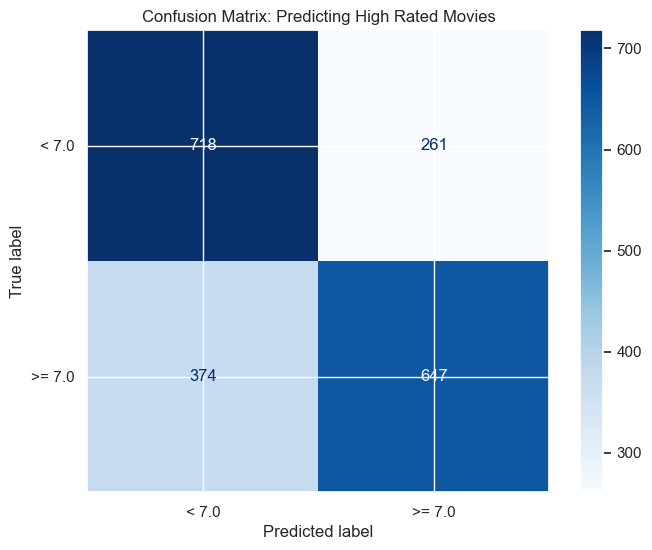

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.73      0.69       979
           1       0.71      0.63      0.67      1021

    accuracy                           0.68      2000
   macro avg       0.69      0.68      0.68      2000
weighted avg       0.69      0.68      0.68      2000



In [123]:
# Initialize and Train Model
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

# Predictions
y_pred = classifier.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['< 7.0', '>= 7.0'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix: Predicting High Rated Movies")
plt.show()

# Classification Report (Includes F1 Score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

### Learning Curve
The learning curve visualizes the performance of the model varying the amount of training data. It shows how the training and validation scores evolve, indicating if the model suffers from high bias (underfitting) or high variance (overfitting).

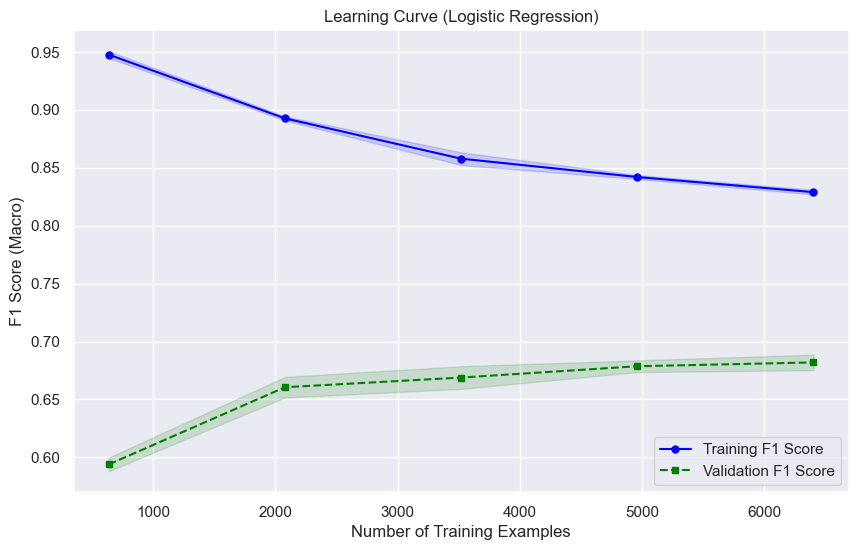

In [124]:
# Generate Learning Curve Data
train_sizes, train_scores, test_scores = learning_curve(
    estimator=classifier,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 5),
    cv=5,
    n_jobs=-1,
    scoring='f1_macro'
)

# Calculate mean and standard deviation for training and testing scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotting the Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training F1 Score')
plt.fill_between(train_sizes, train_mean + train_std, train_mean - train_std, alpha=0.15, color='blue')

plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation F1 Score')
plt.fill_between(train_sizes, test_mean + test_std, test_mean - test_std, alpha=0.15, color='green')

plt.title('Learning Curve (Logistic Regression)')
plt.xlabel('Number of Training Examples')
plt.ylabel('F1 Score (Macro)')
plt.grid(True)
plt.legend(loc='lower right')
plt.show()